In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [2]:
import datajoint as dj
import numpy as np
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta

from tensorpac import Pac, PreferredPhase, EventRelatedPac
from tensorpac.stats import test_stationarity
from tensorpac.utils import pac_trivec, ITC, PeakLockedTF

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
dj.config.load("dj_local_conf_worker.json")
dj.conn()

[2026-02-26 13:01:06,962][INFO]: DataJoint is configured from c:\Users\Organoid PC\Documents\GitHub\utah_organoids\dj_local_conf_worker.json
[2026-02-26 13:01:07,328][INFO]: DataJoint 0.14.4 connected to utah-worker@db.datajoint.com:3306


DataJoint connection (connected) utah-worker@db.datajoint.com:3306

In [4]:
from workflow.pipeline import ephys, analysis, frame

Module stfio is not installed. Make sure .abf files are converted to .pkl in Python 2.


In [5]:
# Input necessary information
organoid_id = "O09"
start_time = datetime(2023, 5, 4, 4, 12, 52) 
end_time = datetime(2023, 5, 4, 4, 27, 52)

In [6]:
ephys_key = (ephys.EphysSession & f"organoid_id='{organoid_id}'" & f"start_time>='{start_time}'" & f"end_time<='{end_time}'").fetch1("KEY")
ephys.EphysSession & ephys_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,session_type
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,both


In [7]:
electrode = 26
trace_key = (ephys.LFP.Trace & ephys_key & f"electrode = {electrode}").fetch1("KEY")

ephys.LFP.Trace & trace_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,electrode_config_hash,probe_type e.g. A1x32-6mm-100-177-H32_21mm,"electrode electrode index, starts at 0",lfp
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,26,=BLOB=


## Select parameters for Tensorpac
Parameters for Tensorpac are stored in the `TensorpacParamset` table.

The following parameters are needed to run coupling analyses using Tensorpac:
- `idpac`: tuple of three integers specifying the type of phase-amplitude coupling analysis to be performed. 
    - `First Index:` Method for extracting phase amplitude coupling
        1) **Mean Vector Length (MVL):** Computes PAC as the length of the average complex vector formed by high‑frequency amplitude weighted onto low‑frequency phase angles, so stronger phase‑locked amplitude concentration yields a larger vector length. 
        2) **Modulation Index (MI):** Measures PAC by comparing the observed phase–amplitude distribution to a uniform distribution using Kullback–Leibler divergence, with higher MI indicating stronger deviation from uniform (stronger coupling).
        3) **Heights Ratio (HR):** Quantifies PAC by taking the ratio between the highest and lowest bins of the phase‑binned amplitude histogram, capturing how much the maximum phase bin stands out above the minimum.
        4) **ndPAC:** A “normalized direct PAC” that computes a direct phase–amplitude coupling measure (similar to MVL/dPAC) and then normalizes it (typically using surrogates or variance estimates) to reduce bias and make values more comparable
        5) **Phase-Locking Value (PLV):** Uses the phase of the low‑frequency signal and the phase of the Hilbert‑transformed high‑frequency amplitude envelope, and quantifies PAC as the consistency (locking) of their phase difference across time.
        6) **Gaussian Copula PAC (GCPAC):** Estimates PAC by transforming phase and amplitude variables through a Gaussian copula framework, providing a more robust, distribution‑free dependence measure that can better handle non‑Gaussian marginal distributions.
    - `Second Index:` Method for computing surrogates: 

        0) **No surrogates:** Uses the observed PAC values directly without generating a null distribution, so you cannot assess statistical significance or correct for bias.
        1) **Swap phase / amplitude across trials:** Breaks true phase–amplitude relationships by pairing phases from one trial with amplitudes from another, preserving within‑trial properties but destroying cross‑frequency coupling to form a trial‑shuffled null.
        2) **Swap amplitude time blocks:** Cuts the amplitude time series into blocks and permutes their order, keeping the amplitude’s spectrum and distribution intact while disrupting its temporal alignment with phase to create a conservative surrogate.
        3) **Time lag:** Introduces a temporal shift (circular time lag) between the phase and amplitude signals from the same trial, preserving their individual statistics but destroying their precise phase–amplitude alignment to generate a null distribution.
    - `Third Index:` Normalization method for correction

        0) **No normalization:** Uses raw PAC values directly, without any correction relative to the surrogate distribution.
        1) **Subtract the mean of surrogates:** Centers the observed PAC by subtracting the surrogate mean, giving a deviation-from-null measure but still in the original PAC units.
        2) **Divide by the mean of surrogates:** Scales the observed PAC by the surrogate mean, expressing coupling relative to the average null level (e.g., as a fold-change).   
        3) **Subtract then divide by the mean of surrogates:** First subtracts, then divides by the surrogate mean, yielding a normalized effect size that reflects both offset and relative magnitude of PAC above null.
        4) **Z-score:** Standardizes PAC by subtracting the surrogate mean and dividing by the surrogate standard deviation, giving values in standard deviation units that can be directly related to p‑values under normality assumptions.
- `dcomplex`: {'wavelet', 'hilbert'} method for extracting the complex components of the signal.
- `cycle_or_width`: Length of method used to extract complex components:
    - For 'hilbert', `cycle (phase,amplitude)` is the number of cycles for fitting
    - For 'wavelet', `width` is the wavelet width parameter.
- `dt`: Amount of time (in seconds) per epoch (recorded trace will be divided into epochs of this length for analysis)

In [8]:
# choose a set of Tensorpac parameters

tensorpac_param_idx = 0

frame.TensorpacParamset()

tensorpac_param_idx Unique identifier for the Tensorpac parameter set,"idpac tuple containing (PAC method, surrogate method, normalization method)",dcomplex method for calculating complex phase ('wavelet' or 'hilbert'),"cycles number of cycles for wavelet convolution (phase, amplitude) (if dcomplex='wavelet')",width width of morlet wavelet (if dcomplex='wavelet'),dt time step in seconds for calculating PAC over time (length of epoch)
0,=BLOB=,wavelet,=BLOB=,7.0,10.0


**Define frequency bands for phase and amplitude:**
f_pha, f_amp: list/tuple/array | def: [2, 4] and [60, 200]
Frequency vector for the phase and amplitude. Here you can use several forms to define those vectors :
- Basic list/tuple (ex: [2, 4] or [8, 12]…)
- List of frequency bands (ex: [[2, 4], [5, 7]]…)
- Dynamic definition : (start, stop, width, step)
- Range definition (ex : np.arange(3) => [[0, 1], [1, 2]])
- Using a string. f_pha and f_amp can be ‘lres’, ‘mres’, ‘hres’ respectively for low, middle and high resolution vectors.
    - i.e f_pha = [f - f / 4, f + f / 4] and f_amp = [f - f / 8, f + f / 8]

In [9]:
# insert phase and amplitude frequency bands of interest for this coupling session

band_param_idx = 0

f_pha = [[4, 6], [6, 8], [8, 10], [10, 12], [12, 14], [14, 16]]
f_amp = [[20, 25], [25, 30], [30, 35], [35, 40], [40, 45], [45, 50]]

band_key = {
    "band_param_idx": band_param_idx,
    "f_pha": f_pha,
    "f_amp": f_amp
}

frame.PhaseAmplitudeBands.insert1(band_key, skip_duplicates=True)
frame.PhaseAmplitudeBands & f"band_param_idx = {band_param_idx}"

band_param_idx Unique identifier for the frequency band parameter set,f_pha phase frequencies of interest (see CREATE_new_coupling_session for details),f_amp amplitude frequencies of interest (see CREATE_new_coupling_session for details)
0,=BLOB=,=BLOB=


In [10]:
# insert all information into manual table
key = {
    **trace_key,
    "tensorpac_param_idx": tensorpac_param_idx,
    "band_param_idx": band_param_idx
}

frame.CouplingSession.insert1(key, skip_duplicates=True)
frame.CouplingSession & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,electrode_config_hash,probe_type e.g. A1x32-6mm-100-177-H32_21mm,"electrode electrode index, starts at 0",tensorpac_param_idx Unique identifier for the Tensorpac parameter set,band_param_idx Unique identifier for the frequency band parameter set
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,26,0,0


In [11]:
# populate the CouplingSession table to run tensorpac analysis
# frame.PhaseAmplitudeCoupling.populate()

frame.PhaseAmplitudeCoupling & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,electrode_config_hash,probe_type e.g. A1x32-6mm-100-177-H32_21mm,"electrode electrode index, starts at 0",tensorpac_param_idx Unique identifier for the Tensorpac parameter set,band_param_idx Unique identifier for the frequency band parameter set,pha_vec phase frequency bin (center frequencies),amp_vec amplitude frequency bin (center frequencies),"pac_array PAC values for each phase-amplitude pair (shape: amp_vec, pha_vec, num_epochs)","pvalues p-values for each phase-amplitude pair (shape: amp_vec, pha_vec)"
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,26,0,0,=BLOB=,=BLOB=,=BLOB=,=BLOB=


The `PhaseAmplitudeCoupling` table stores the results of PAC analysis. It includes:
- `pha_vec`: vector of phase frequencies used in the analysis.
- `amp_vec`: vector of amplitude frequencies used in the analysis.
- `pac_array`: the computed PAC values for each combination of phase and amplitude frequencies.
- `pvalues`: the p-values associated with the PAC values, indicating their statistical significance based on the surrogate (null) distribution.

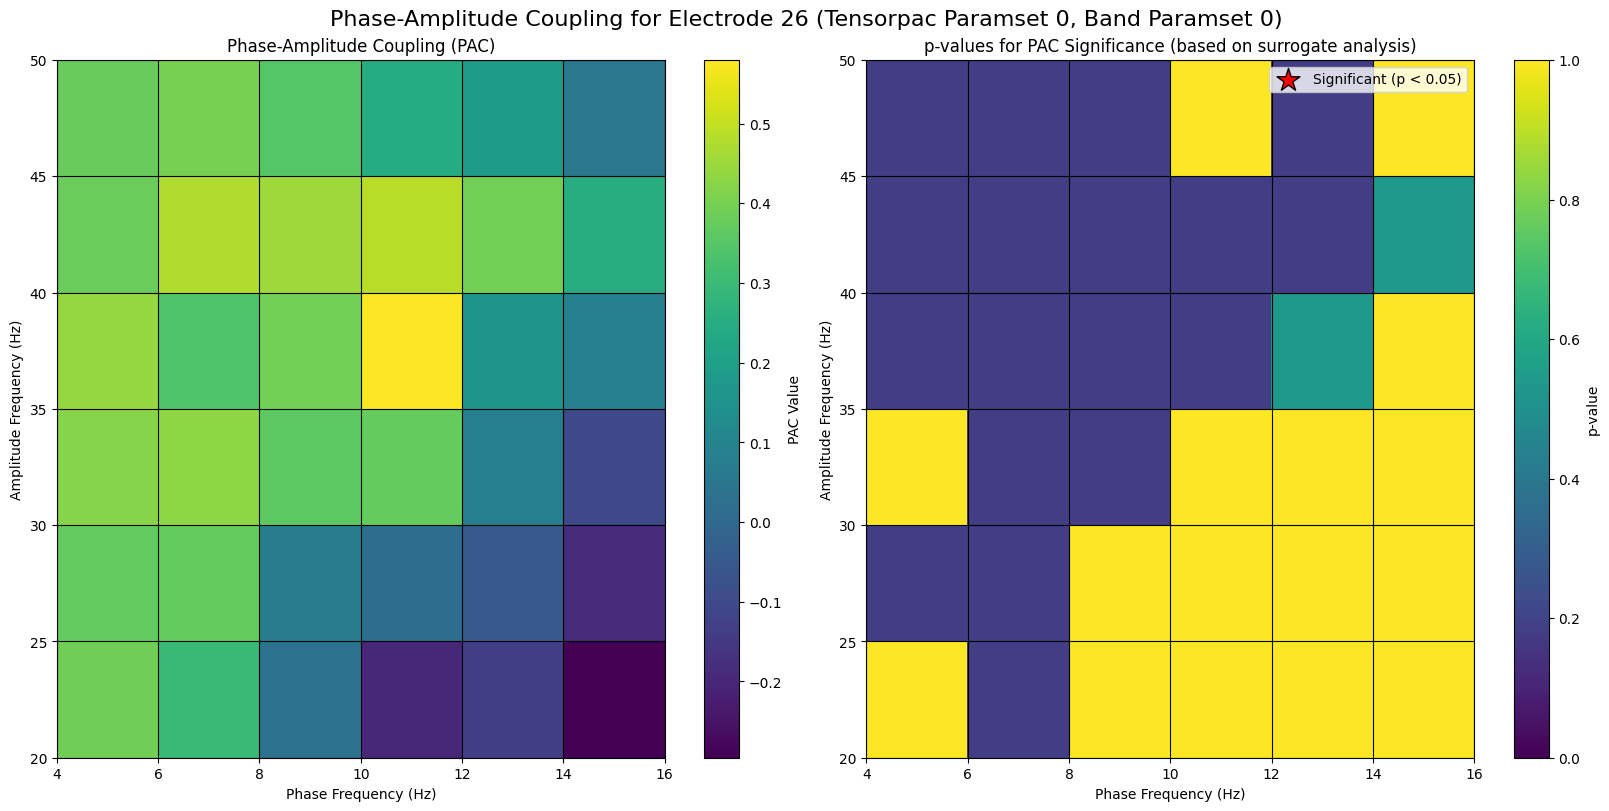

In [12]:
# plot PAC and pvalue arrays
pha_vec, amp_vec, pac_array, pvalues = (frame.PhaseAmplitudeCoupling & key).fetch1("pha_vec", "amp_vec", "pac_array", "pvalues")

# get frequency band
f_pha, f_amp = (frame.PhaseAmplitudeBands & key).fetch1("f_pha", "f_amp")
f_pha_bins = np.unique(np.array(f_pha).flatten())
f_amp_bins = np.unique(np.array(f_amp).flatten())

# average across epochs
pac = pac_array.mean(axis=-1)   


# find pvalues lower than .05
significant_mask = pvalues < 0.05
if significant_mask.any():
    # find the indices of significant values
    significant_indices = np.argwhere(significant_mask)


# plot figures
fig, axs = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)
fig.suptitle(f"Phase-Amplitude Coupling for Electrode {electrode} (Tensorpac Paramset {tensorpac_param_idx}, Band Paramset {band_param_idx})", fontsize=16)

# plot PAC
im = axs[0].imshow(pac, aspect='auto', origin='lower', extent=[f_pha_bins[0], f_pha_bins[-1], f_amp_bins[0], f_amp_bins[-1]])
fig.colorbar(im, ax=axs[0], label='PAC Value')

axs[0].set_xlabel('Phase Frequency (Hz)')
axs[0].set_ylabel('Amplitude Frequency (Hz)')
axs[0].set_xticks(f_pha_bins)
axs[0].set_yticks(f_amp_bins)
axs[0].set_title('Phase-Amplitude Coupling (PAC)')
axs[0].grid(color='black')


# plot pvalues
im = axs[1].imshow(pvalues, aspect='auto', origin='lower', extent=[f_pha_bins[0], f_pha_bins[-1], f_amp_bins[0], f_amp_bins[-1]], cmap='viridis', vmin=0, vmax=1)
fig.colorbar(im, ax=axs[1], label='p-value')

# plot significant values with a red star
if significant_mask.any():
    axs[1].scatter(f_pha_bins[significant_indices[:, 1]]+np.diff(f_pha, axis=1)[significant_indices[:, 1]]/2, f_amp_bins[significant_indices[:, 0]]+np.diff(f_amp, axis=1)[significant_indices[:, 0]]/2,
                    s=300, color='red', edgecolors='black', marker='*')

axs[1].set_xlabel('Phase Frequency (Hz)')
axs[1].set_ylabel('Amplitude Frequency (Hz)')
axs[1].set_xticks(f_pha_bins)
axs[1].set_yticks(f_amp_bins)
axs[1].set_title('p-values for PAC Significance (based on surrogate analysis)')
axs[1].grid(color='black')

# for legend
axs[1].scatter([], [], s=300, color='red', edgecolors='black', marker='*', label='Significant (p < 0.05)')
axs[1].legend(loc='upper right')

plt.show()

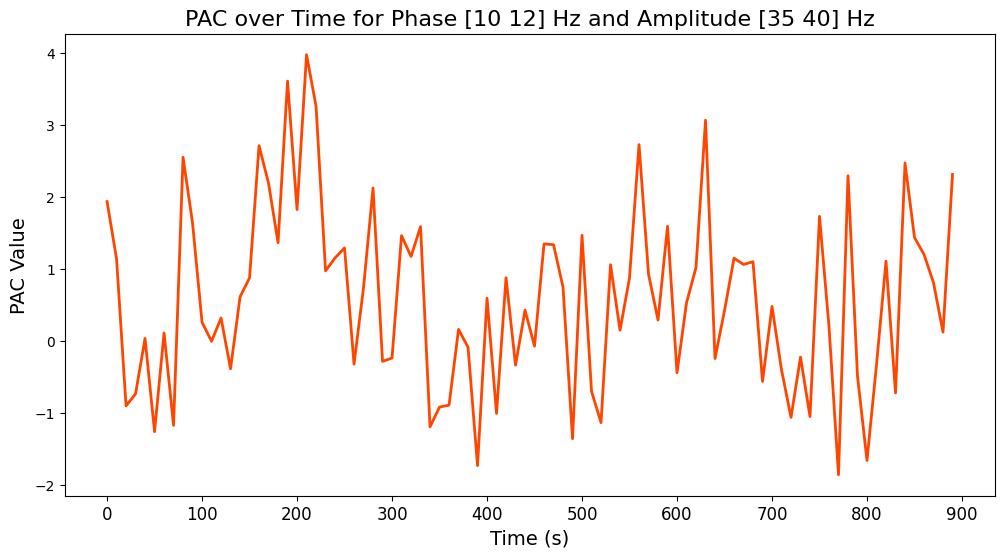

In [13]:
# Plot single phase-amplitude pair across session

# define pair
amp_idx = 3 # starting from bottom
pha_idx = 3 # starting from left

# get phase and amplitude vectors for this pair
pac_vec = pac_array[amp_idx, pha_idx, :]
num_epochs = len(pac_vec)

# get time vector
dt = (frame.TensorpacParamset & key).fetch1("dt")
t = np.arange(num_epochs) * dt

# plot
plt.figure(figsize=(12, 6))
plt.plot(t, pac_vec, linewidth=2, color='orangered')

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('PAC Value', fontsize=14)
plt.title(f'PAC over Time for Phase {np.array(f_pha)[pha_idx,:]} Hz and Amplitude {np.array(f_amp)[amp_idx,:]} Hz', fontsize=16)
plt.xticks(np.arange(0, t[-1]+100, 100), fontsize=12)

plt.show()

In [14]:
frame.PhaseAmplitudeCoupling.PreferredPhase & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,electrode_config_hash,probe_type e.g. A1x32-6mm-100-177-H32_21mm,"electrode electrode index, starts at 0",tensorpac_param_idx Unique identifier for the Tensorpac parameter set,band_param_idx Unique identifier for the frequency band parameter set,"preferred_phase preferred phase for each amplitude frequency (shape: amp_vec, pha_vec, num_epochs)",vecbin phase bins (-pi to pi) (shape: n_bins),"amplitude_values amplitude values for each phase bin (shape: n_bins, amp_vec, pha_vec, num_epochs)"
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,26,0,0,=BLOB=,=BLOB=,=BLOB=


The `PreferredPhase` table stores the relavent metrics for preferred phase analysis. In summary, preferred phase analysis identifies the specific phase of a low-frequency oscillation at which the amplitude of a high-frequency oscillation is maximized, providing insights into the timing of cross-frequency interactions in neural signals. The `PreferredPhase` table includes:
- `preferred_phase`: the preferred phase for each amplitude frequency (shape: amp_vec, pha_vec, num_epochs)
- `vecbin`: phase bins (-pi to pi) (shape: n_bins)
- `amplitude_values`: amplitude values for each phase bin (shape: n_bins, amp_vec, pha_vec, num_epochs)

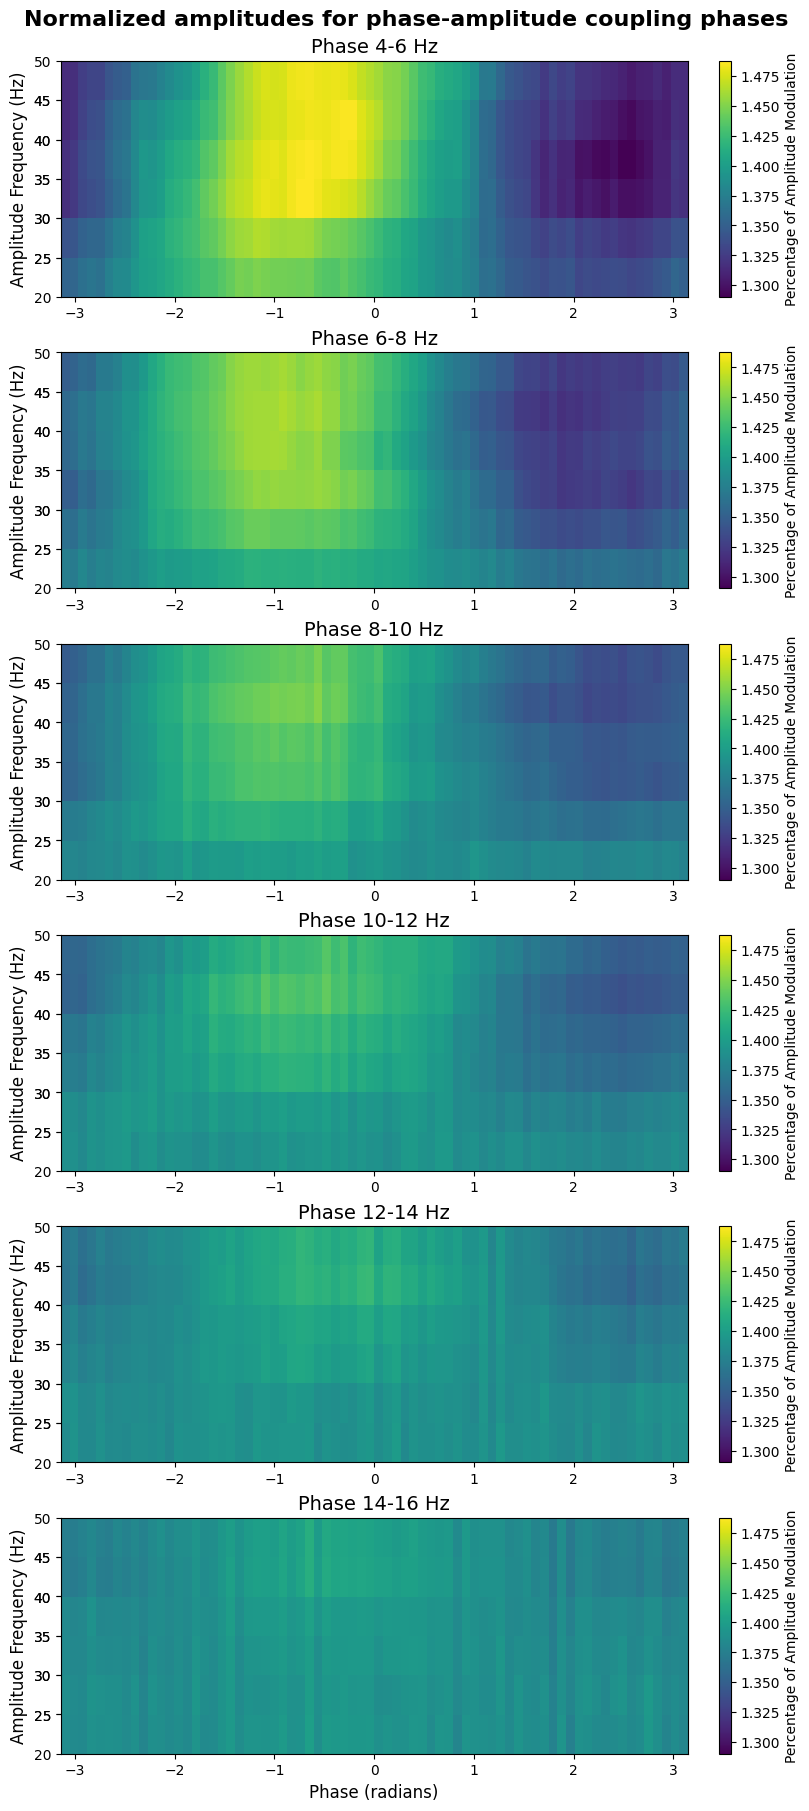

In [15]:
# Plot mean amplitude (across epochs) across amplitude frequency bands for each phase frequency band

# fetch bands
phase_bands, amplitude_bands = (frame.PhaseAmplitudeBands & key).fetch1("f_pha", "f_amp")

# fetch preferred phase results
vecbin, amplitude_values = (frame.PhaseAmplitudeCoupling.PreferredPhase & key).fetch1("vecbin", "amplitude_values")

# average across epochs (convert to percentage)
mean_amplitude_values = amplitude_values.mean(axis=-1) * 100

# plot
num_phase_bands = len(phase_bands)
fig, axs = plt.subplots(num_phase_bands, 1, figsize=(8, 3*num_phase_bands), constrained_layout=True)
fig.suptitle(f'Normalized amplitudes for phase-amplitude coupling phases', fontsize=16, fontweight='bold')

for i, (phase_band, ax) in enumerate(zip(phase_bands, axs)):

    im = ax.imshow(mean_amplitude_values[:, :, i].T, aspect='auto', origin='lower', extent=[vecbin[0], vecbin[-1], amplitude_bands[0][0], amplitude_bands[-1][1]], vmin=mean_amplitude_values.min(), vmax=mean_amplitude_values.max(), cmap='viridis')
    cbar = fig.colorbar(im, ax=ax, label='Percentage of Amplitude Modulation')

    ax.set_title(f'Phase {phase_band[0]}-{phase_band[1]} Hz', fontsize=14)
    ax.set_ylabel('Amplitude Frequency (Hz)', fontsize=12)
    ax.set_yticks(np.array(amplitude_bands).flatten())
ax.set_xlabel('Phase (radians)', fontsize=12)

plt.show()

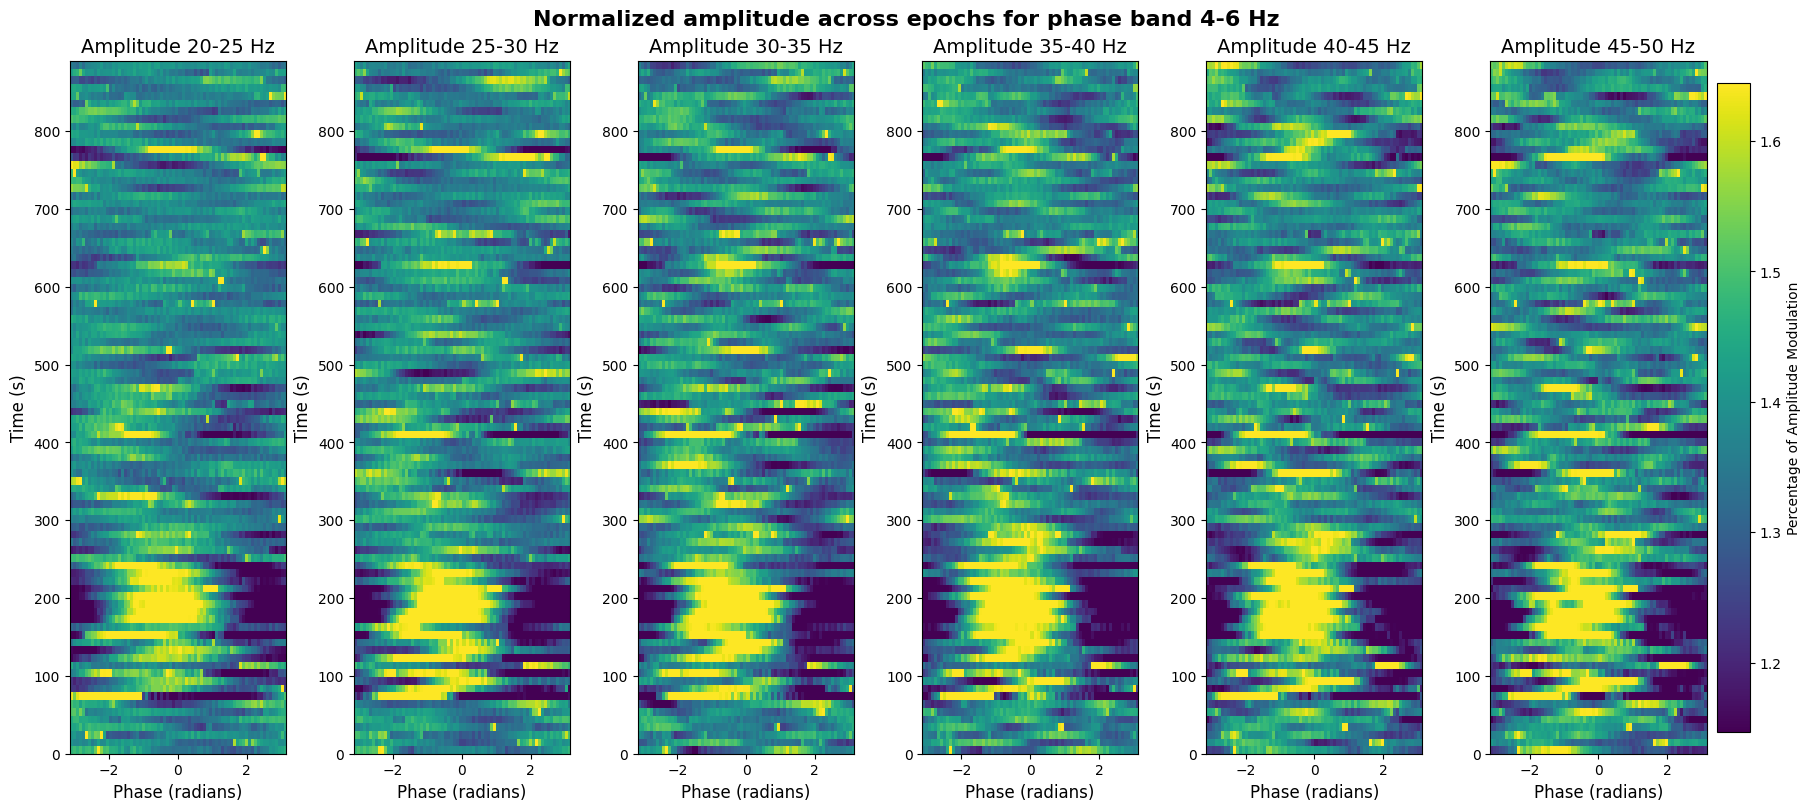

In [16]:
# Look at a single phase bands preferred phase across epochs (for each amplitude band)

# fetch bands
phase_bands, amplitude_bands = (frame.PhaseAmplitudeBands & key).fetch1("f_pha", "f_amp")

# fetch preferred phase results
vecbin, amplitude_values = (frame.PhaseAmplitudeCoupling.PreferredPhase & key).fetch1("vecbin", "amplitude_values")

# convert to percentage
amplitude_values = amplitude_values * 100

# choose a single phase band and amplitude band
selected_band = [4, 6]
phase_band_idx = np.where((np.array(phase_bands) == selected_band).all(axis=1))[0][0]

band_amplitude_values = amplitude_values[:, :, phase_band_idx, :]

# get time vector from epochs
dt = (frame.TensorpacParamset & key).fetch1("dt")
time_vector = np.arange(band_amplitude_values.shape[-1]) * dt

# plot
fig, axs = plt.subplots(1, len(amplitude_bands), figsize=(3*len(amplitude_bands), 8), constrained_layout=True)
fig.suptitle(f'Normalized amplitude across epochs for phase band {selected_band[0]}-{selected_band[1]} Hz', fontsize=16, fontweight='bold')

cmin = np.percentile(band_amplitude_values, 5)
cmax = np.percentile(band_amplitude_values, 95)

for i, (amplitude_band, ax) in enumerate(zip(amplitude_bands, axs)):

    im = ax.imshow(band_amplitude_values[:, i, :].T, aspect='auto', origin='lower', extent=[vecbin[0], vecbin[-1], 0, time_vector[-1]], vmin=cmin, vmax=cmax, cmap='viridis')
    ax.set_title(f'Amplitude {amplitude_band[0]}-{amplitude_band[1]} Hz', fontsize=14)
    ax.set_xlabel('Phase (radians)', fontsize=12)
    ax.set_ylabel('Time (s)', fontsize=12)

fig.colorbar(im, ax=ax, label='Percentage of Amplitude Modulation', location='right')

plt.show()

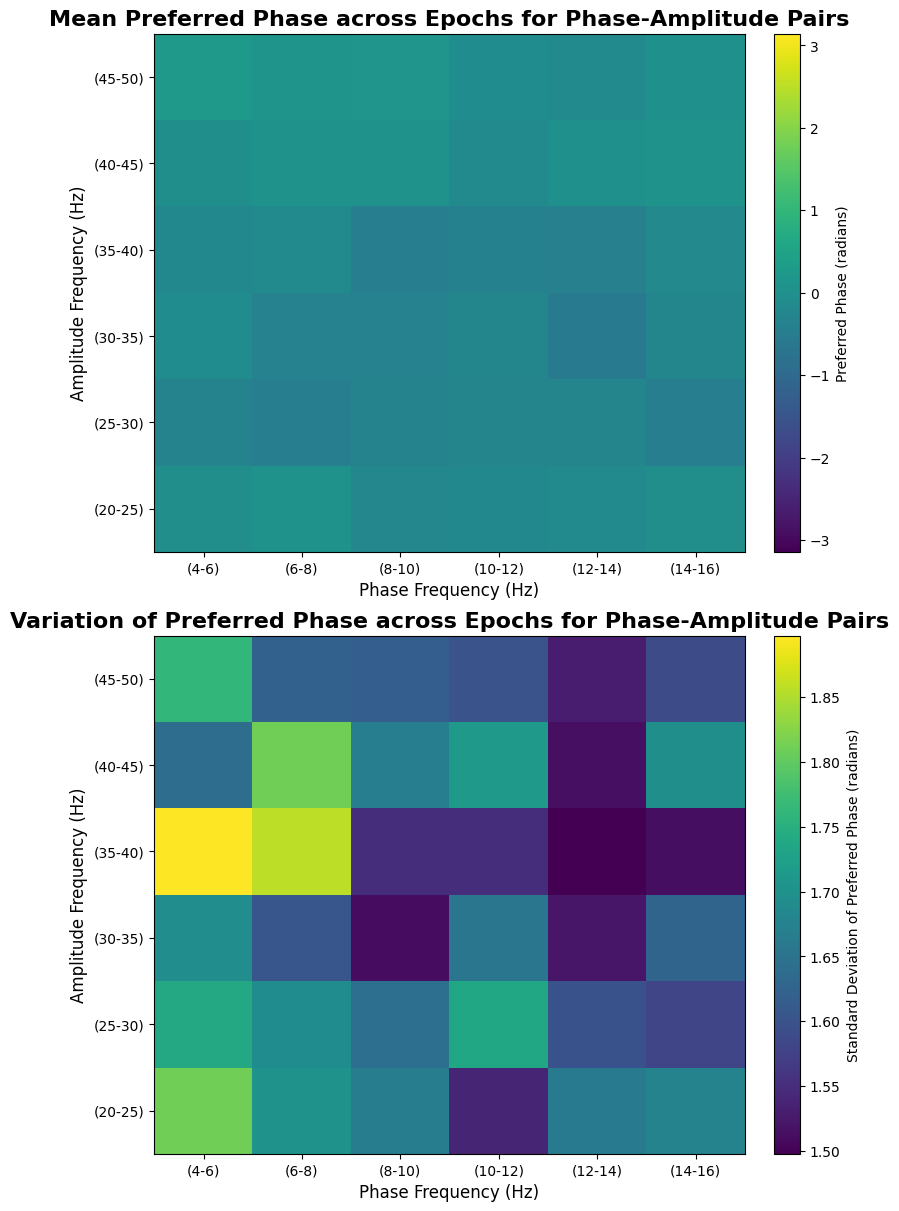

In [17]:
# Plot mean preferred phase across epochs for each phase-amplitude pair

# fetch bands
phase_bands, amplitude_bands = (frame.PhaseAmplitudeBands & key).fetch1("f_pha", "f_amp")

# fetch preferred phase results
vecbin, preferred_phases = (frame.PhaseAmplitudeCoupling.PreferredPhase & key).fetch1("vecbin", "preferred_phase")

# average across epochs 
mean_phases = np.mean(preferred_phases, axis=-1)
phase_variation = np.std(np.abs(preferred_phases-np.pi), axis=-1)

# plot
fig, axs = plt.subplots(2, 1, figsize=(8, 12), constrained_layout=True)

# mean values
im = axs[0].imshow(mean_phases.T, aspect='auto', origin='lower', vmin=-np.pi, vmax=np.pi, cmap='viridis')
cbar = fig.colorbar(im, ax=axs[0], label='Preferred Phase (radians)')
axs[0].set_title(f'Mean Preferred Phase across Epochs for Phase-Amplitude Pairs', fontsize=16, fontweight='bold')
axs[0].set_xlabel('Phase Frequency (Hz)', fontsize=12)
axs[0].set_ylabel('Amplitude Frequency (Hz)', fontsize=12)
axs[0].set_xticks(np.arange(len(phase_bands)))
axs[0].set_yticks(np.arange(len(amplitude_bands)))
axs[0].set_xticklabels([f"({pband[0]}-{pband[1]})" for pband in phase_bands])
axs[0].set_yticklabels([f"({aband[0]}-{aband[1]})" for aband in amplitude_bands])

# std values
im = axs[1].imshow(phase_variation.T, aspect='auto', origin='lower', cmap='viridis')
cbar = fig.colorbar(im, ax=axs[1], label='Standard Deviation of Preferred Phase (radians)')
axs[1].set_title(f'Variation of Preferred Phase across Epochs for Phase-Amplitude Pairs', fontsize=16, fontweight='bold')
axs[1].set_xlabel('Phase Frequency (Hz)', fontsize=12)
axs[1].set_ylabel('Amplitude Frequency (Hz)', fontsize=12)
axs[1].set_xticks(np.arange(len(phase_bands)))
axs[1].set_yticks(np.arange(len(amplitude_bands)))
axs[1].set_xticklabels([f"({pband[0]}-{pband[1]})" for pband in phase_bands])
axs[1].set_yticklabels([f"({aband[0]}-{aband[1]})" for aband in amplitude_bands])

plt.show()

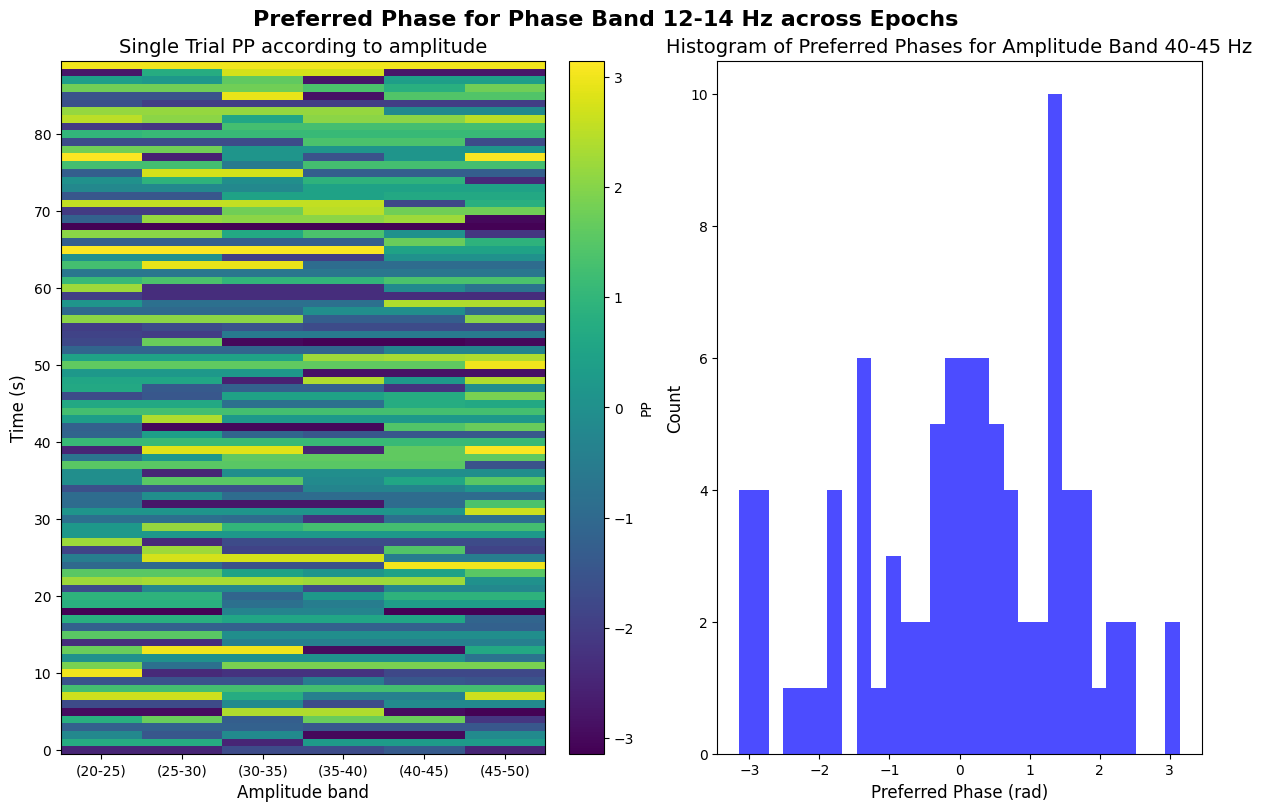

In [18]:
# Plot the preferred phase for a single phase band across epochs

# fetch bands
phase_bands, amplitude_bands = (frame.PhaseAmplitudeBands & key).fetch1("f_pha", "f_amp")

# fetch preferred phase results
vecbin, preferred_phases = (frame.PhaseAmplitudeCoupling.PreferredPhase & key).fetch1("vecbin", "preferred_phase")

# choose a single phase band and amplitude band
selected_band = [12, 14]
phase_band_idx = np.where((np.array(phase_bands) == selected_band).all(axis=1))[0][0]

band_preferred_phases = preferred_phases[:, phase_band_idx, :]

# get time vector from epochs
dt = (frame.TensorpacParamset & key).fetch1("dt")
time_vector = np.arange(band_preferred_phases.shape[-1]) * dt

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 8), constrained_layout=True)
fig.suptitle(f'Preferred Phase for Phase Band {selected_band[0]}-{selected_band[1]} Hz across Epochs', fontsize=16, fontweight='bold')

im = axs[0].imshow(band_preferred_phases.T, aspect='auto', origin='lower', vmin=-np.pi, vmax=np.pi, cmap='viridis')
axs[0].set_title(f'Single Trial PP according to amplitude', fontsize=14)
axs[0].set_xlabel('Amplitude band', fontsize=12)
axs[0].set_xticks(np.arange(len(amplitude_bands)))
axs[0].set_xticklabels([f"({aband[0]}-{aband[1]})" for aband in amplitude_bands])
axs[0].set_ylabel('Time (s)', fontsize=12)

fig.colorbar(im, ax=axs[0], label='PP', location='right')

# Plot histogram of preferred phases for a single amplitude band

selected_amp_band = [40, 45]
amp_band_idx = np.where((np.array(amplitude_bands) == selected_amp_band).all(axis=1))[0][0]

axs[1].hist(band_preferred_phases[amp_band_idx, :], bins=30, range=(-np.pi, np.pi), color='blue', alpha=0.7)
axs[1].set_title(f'Histogram of Preferred Phases for Amplitude Band {selected_amp_band[0]}-{selected_amp_band[1]} Hz', fontsize=14)
axs[1].set_xlabel('Preferred Phase (rad)', fontsize=12)
axs[1].set_ylabel('Count', fontsize=12)

plt.show()

## Event Coupling Analysis with Tensorpac

Phase-amplitude coupling can also be analyzed in relation to specific events (e.g., spikes, behavioral events) using the `EventBasedCoupling` table. This analysis involves aligning the LFP data to the timing of events and then computing PAC in a time-resolved manner around those events. Understanding the temporal dynamics of PAC in relation to events can provide insights into how neural oscillations coordinate information processing during specific moments.

Similar to the session based phase amplitude coupling, event based coupling analysis is structured based on the parameter tables `TensorpacParamset` to specify the parameters for the analysis, and `PhaseAmplitudeBands` to specify the frequency bands for phase and amplitude. These parameters are inserted into the `EventCouplingSession` table, which serves as a session-level entry for each unique combination of parameters. The actual coupling results are stored in the `EventBasedCoupling` table, which includes **Event based PAC metrics** as well as two part tables `InterTrialCoherence` and `PeakLockedTF` for storing inter-trial coherence and peak-locked time-frequency amplitude, respectively.

To run event-based coupling, you must first select a single unit which will be used to align the LFP data. 

To run spike sorting, reference **CREATE_new_clustering_task** which describes how to create a new clustering session and run spike sorting. Single-unit results will be stored in `ephys.CuratedClustering.Unit`. You must select a single unit from this table to run event-based coupling.

In [19]:
# Input necessary information
unit_id = 10
unit_key = (ephys.CuratedClustering.Unit & ephys_key & f"unit = '{unit_id}'").fetch1("KEY")

ephys.CuratedClustering.Unit & unit_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,paramset_idx,unit,electrode_config_hash,probe_type e.g. A1x32-6mm-100-177-H32_21mm,"electrode electrode index, starts at 0","cluster_quality_label cluster quality type - e.g. 'good', 'MUA', 'noise', etc.",spike_count how many spikes in this recording for this unit,"spike_times (s) spike times of this unit, relative to the start of the EphysRecording",spike_sites array of electrode associated with each spike,"spike_depths (um) array of depths associated with each spike, relative to the (0, 0) of the probe"
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,301,10,699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,16,mua,459,=BLOB=,=BLOB=,=BLOB=


After selecting the unit, you can create a new coupling session by inserting the relevant parameters into the `UnitCouplingSession` table. In each cell below, select a param_idx that's listed in the table.

In [24]:
tensorpac_param_idx = 0

frame.TensorpacParamset()

[2026-02-26 13:13:04,117][WARNING]: Reconnecting to MySQL server.


tensorpac_param_idx Unique identifier for the Tensorpac parameter set,"idpac tuple containing (PAC method, surrogate method, normalization method)",dcomplex method for calculating complex phase ('wavelet' or 'hilbert'),"cycles number of cycles for wavelet convolution (phase, amplitude) (if dcomplex='wavelet')",width width of morlet wavelet (if dcomplex='wavelet'),dt time step in seconds for calculating PAC over time (length of epoch)
0,=BLOB=,wavelet,=BLOB=,7.0,10.0


In [21]:
band_param_idx = 0


frame.PhaseAmplitudeBands()

band_param_idx Unique identifier for the frequency band parameter set,f_pha phase frequencies of interest (see CREATE_new_coupling_session for details),f_amp amplitude frequencies of interest (see CREATE_new_coupling_session for details)
0,=BLOB=,=BLOB=
1,=BLOB=,=BLOB=


Create a new coupling session by inserting the relevant parameters into the `UnitCouplingSession` table. 

In [22]:
event_pac_key = {
    **unit_key,
    "tensorpac_param_idx": tensorpac_param_idx,
    "band_param_idx": band_param_idx
}
frame.UnitCouplingSession.insert1(event_pac_key, skip_duplicates=True)
frame.UnitCouplingSession & event_pac_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,paramset_idx,unit,tensorpac_param_idx Unique identifier for the Tensorpac parameter set,band_param_idx Unique identifier for the frequency band parameter set
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,301,10,0,0


**OPTIONAL:** To populate the session locally reference the cell below. However, this step is not necessary as the session will be automatically populated when the pipeline is running.

`EventBasedCoupling` contain four values:
- `pha_vec`: vector of phase frequencies (center frequency) used in the analysis.
- `amp_vec`: vector of amplitude frequencies (center frequency) used in the analysis.
- `t`: vector of time points relative to the event at which PAC was computed (relative to spike time).
- `erpac_array`: the computed event-related PAC values for each combination of phase and amplitude frequencies across time points.

In [27]:
# frame.EventBasedCoupling.populate(event_pac_key)

frame.EventBasedCoupling & event_pac_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,paramset_idx,unit,tensorpac_param_idx Unique identifier for the Tensorpac parameter set,band_param_idx Unique identifier for the frequency band parameter set,pha_vec phase frequency bin (center frequencies),amp_vec amplitude frequency bin (center frequencies),t time vector relative to spike time,"erpac_array Event-Related PAC values for each phase-amplitude pair (shape: amp_vec, pha_vec, time)"
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,301,10,0,0,=BLOB=,=BLOB=,=BLOB=,=BLOB=


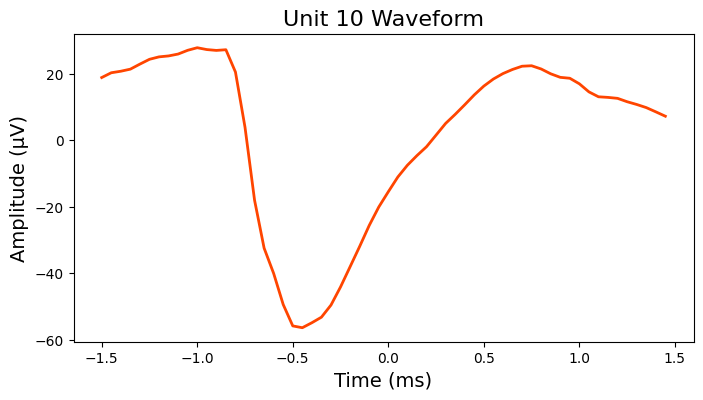

In [34]:
# Plot unit waveform
spike_fs = 20000

unit_waveform = (ephys.WaveformSet.PeakWaveform & unit_key).fetch1("peak_electrode_waveform")
t = np.arange(-1.5, 1.5, 1000/spike_fs)

# plot
plt.figure(figsize=(8, 4))
plt.plot(t, unit_waveform, linewidth=2, color='orangered')
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Amplitude (µV)', fontsize=14)
plt.title(f'Unit {unit_id} Waveform', fontsize=16)

plt.show()

[2026-02-26 14:19:59,047][WARNING]: Reconnecting to MySQL server.


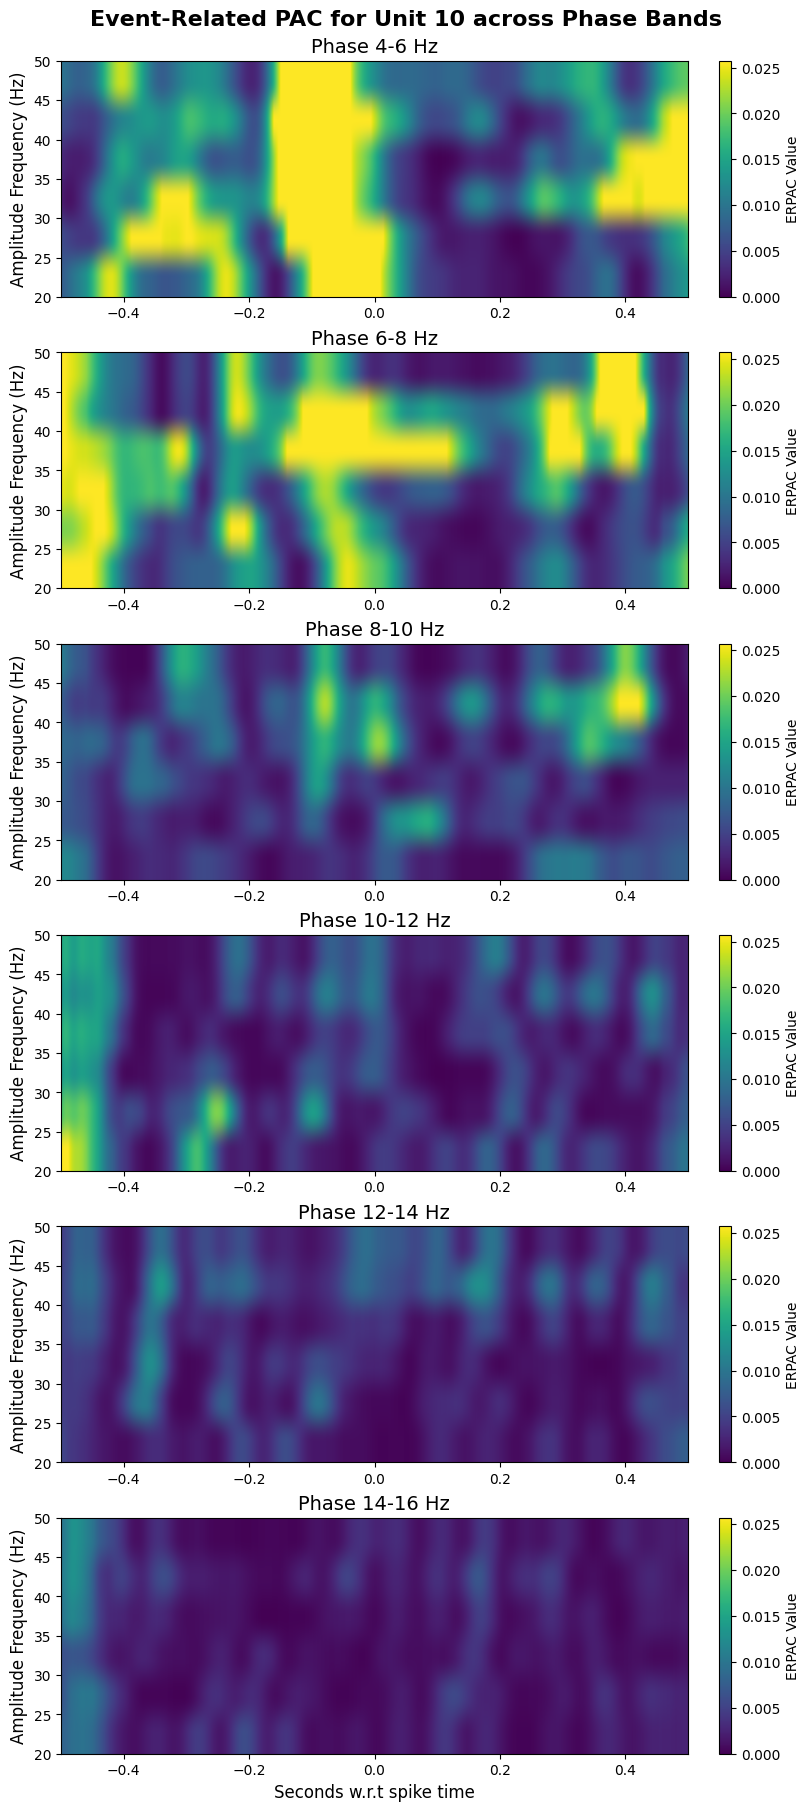

In [64]:
# Plot event-related PAC for each phase frequency band

# fetch frequency bands
f_pha, f_amp = (frame.PhaseAmplitudeBands & event_pac_key).fetch1("f_pha", "f_amp")

# fetch event-related PAC results
t, erpac_array = (frame.EventBasedCoupling & event_pac_key).fetch1("t", "erpac_array")

# plot
num_phase_bands = len(f_pha)
fig, axs = plt.subplots(num_phase_bands, 1, figsize=(8, 3*num_phase_bands), constrained_layout=True)
fig.suptitle(f'Event-Related PAC for Unit {unit_id} across Phase Bands', fontsize=16, fontweight='bold')

cmin = 0
cmax = np.percentile(erpac_array, 95)

for i, (phase_band, ax) in enumerate(zip(f_pha, axs)):
    im = ax.imshow(erpac_array[:, i, :], aspect='auto', origin='lower', extent=[t[0], t[-1], f_amp[0][0], f_amp[-1][1]], vmin=cmin, vmax=cmax, cmap='viridis')
    ax.set_title(f'Phase {phase_band[0]}-{phase_band[1]} Hz', fontsize=14)
    ax.set_ylabel('Amplitude Frequency (Hz)', fontsize=12)
    fig.colorbar(im, ax=ax, label='ERPAC Value', location='right')
ax.set_xlabel('Seconds w.r.t spike time', fontsize=12)

plt.show()


Intertrial Coherence measures the consistency of phase across trials at each time point and frequency, providing insight into how well neural oscillations are phase-locked to events. The `InterTrialCoherence` table includes:
- `itc_array`: the computed intertrial coherence values for each combination of phase frequencies and time points (shape: pha_vec, time).

In [72]:
frame.EventBasedCoupling.InterTrialCoherence & event_pac_key

[2026-02-26 14:34:19,444][WARNING]: Reconnecting to MySQL server.


organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,paramset_idx,unit,tensorpac_param_idx Unique identifier for the Tensorpac parameter set,band_param_idx Unique identifier for the frequency band parameter set,"itc_array ITC values for each phase frequency and time point (shape: pha_vec, time)"
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,301,10,0,0,=BLOB=


[2026-02-26 14:50:44,408][WARNING]: Reconnecting to MySQL server.


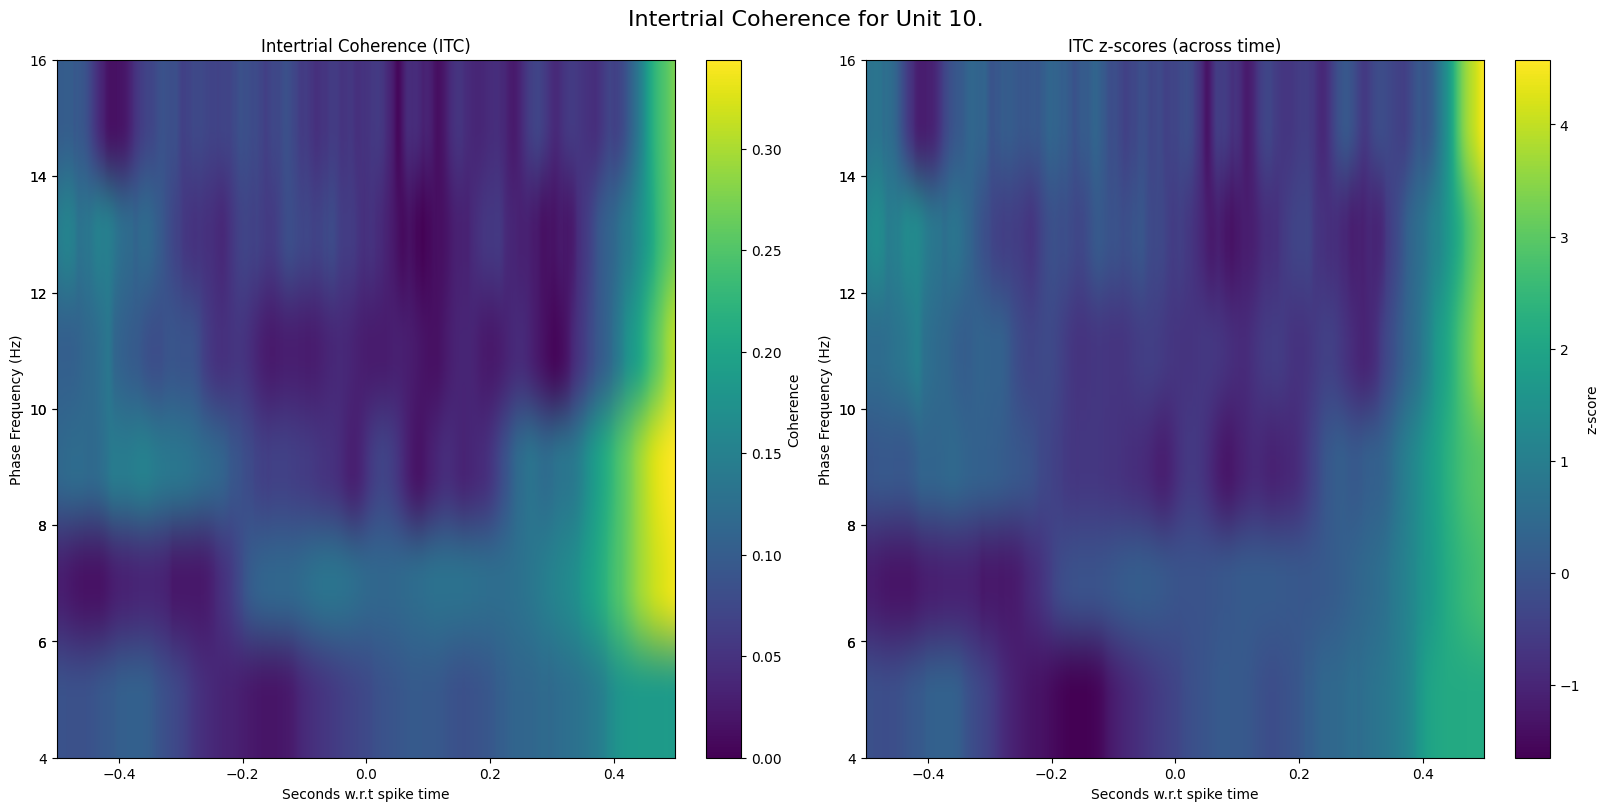

In [87]:
# Plot intertrial coherence (coherence and z-scores)

# fetch frequency bands
f_pha, f_amp = (frame.PhaseAmplitudeBands & event_pac_key).fetch1("f_pha", "f_amp")

# get time vector
t = (frame.EventBasedCoupling & event_pac_key).fetch1("t")

# fetch ITC results
itc_array = (frame.EventBasedCoupling.InterTrialCoherence & event_pac_key).fetch1("itc_array")

# get z-scores
z_scores = (itc_array - np.mean(itc_array, axis=1, keepdims=True)) / np.std(itc_array, axis=1, keepdims=True)

# plot figures
fig, axs = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)
fig.suptitle(f'Intertrial Coherence for Unit {unit_id}.', fontsize=16)

# plot ITC
im = axs[0].imshow(itc_array, aspect='auto', origin='lower', extent=[t[0], t[-1], f_pha[0][0], f_pha[-1][1]], vmin=0, cmap='viridis')
fig.colorbar(im, ax=axs[0], label='Coherence')
axs[0].set_xlabel('Seconds w.r.t spike time')
axs[0].set_ylabel('Phase Frequency (Hz)')
axs[0].set_title('Intertrial Coherence (ITC)')
axs[0].set_yticks(np.array(f_pha).flatten())

# plot z-scores
im = axs[1].imshow(z_scores, aspect='auto', origin='lower', extent=[t[0], t[-1], f_pha[0][0], f_pha[-1][1]], cmap='viridis')
fig.colorbar(im, ax=axs[1], label='z-score')
axs[1].set_xlabel('Seconds w.r.t spike time')
axs[1].set_ylabel('Phase Frequency (Hz)')
axs[1].set_title('ITC z-scores (across time)')
axs[1].set_yticks(np.array(f_pha).flatten())

plt.show()

Peak-locked time-frequency amplitude measures the amplitude of oscillations at different frequencies and time points relative to the event. This analysis will shift the time vector so the nearest phase peak aligns with time 0. The `PeakLockedTF` table includes:
- `pltf_array`: the computed time-frequency amplitude values for each combination of amplitude frequencies and time points (shape: amp_vec, pha_vec, time).

[2026-02-26 15:12:14,087][WARNING]: Reconnecting to MySQL server.


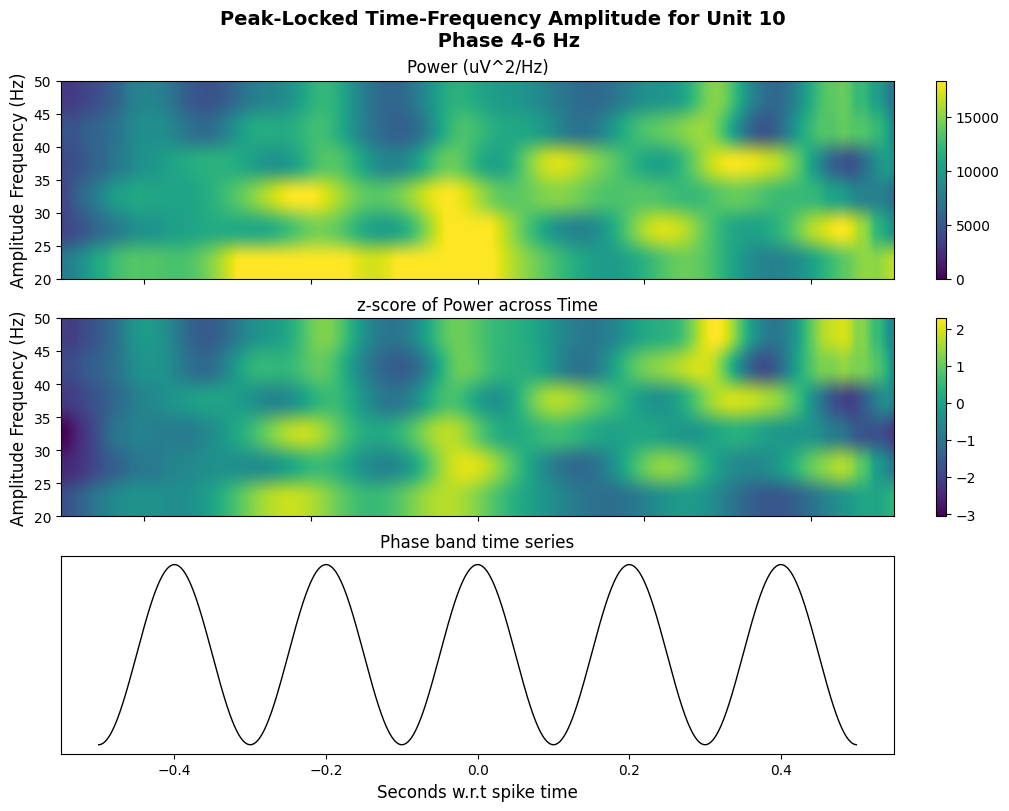

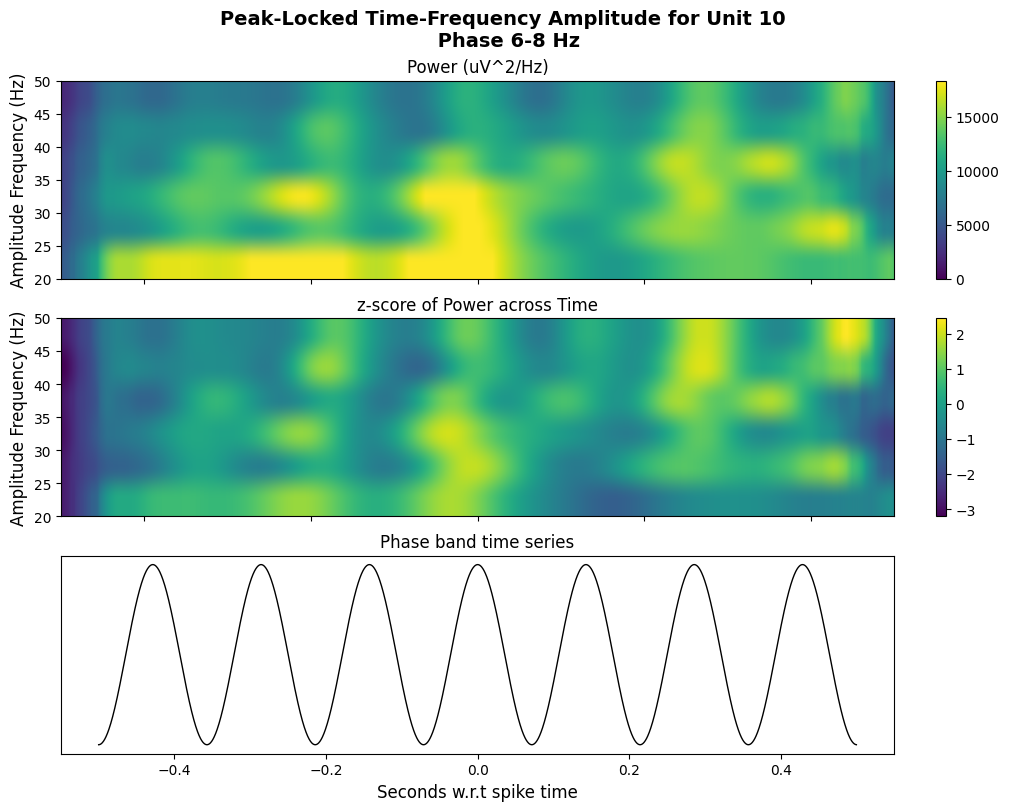

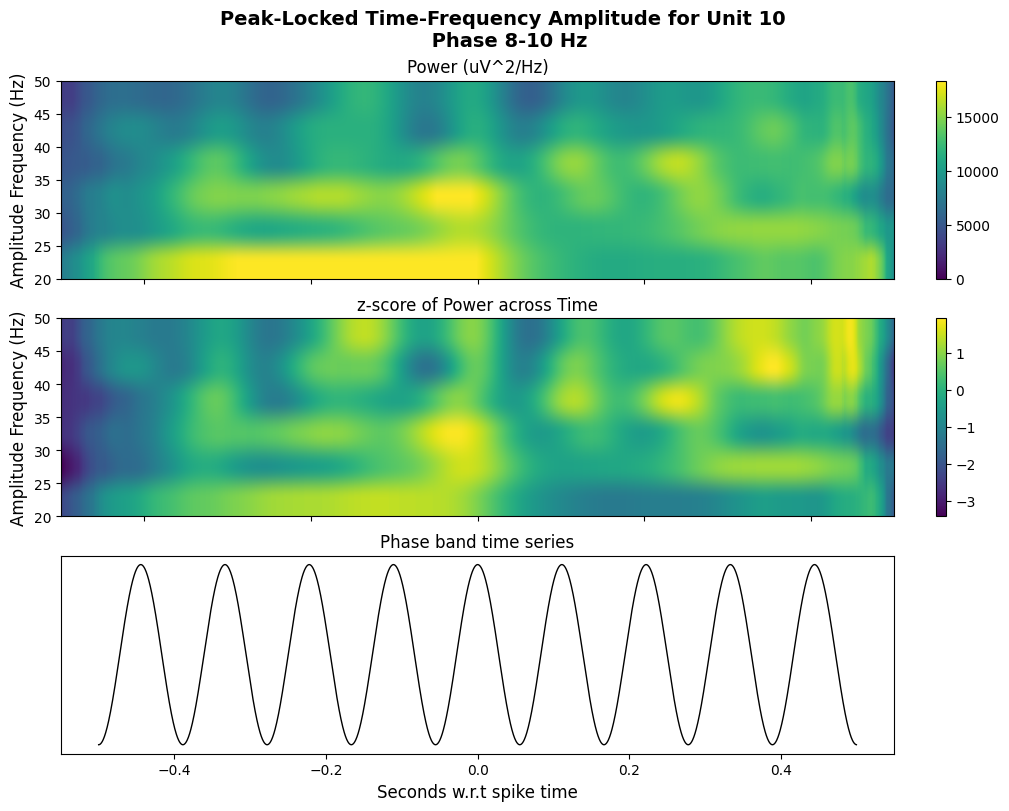

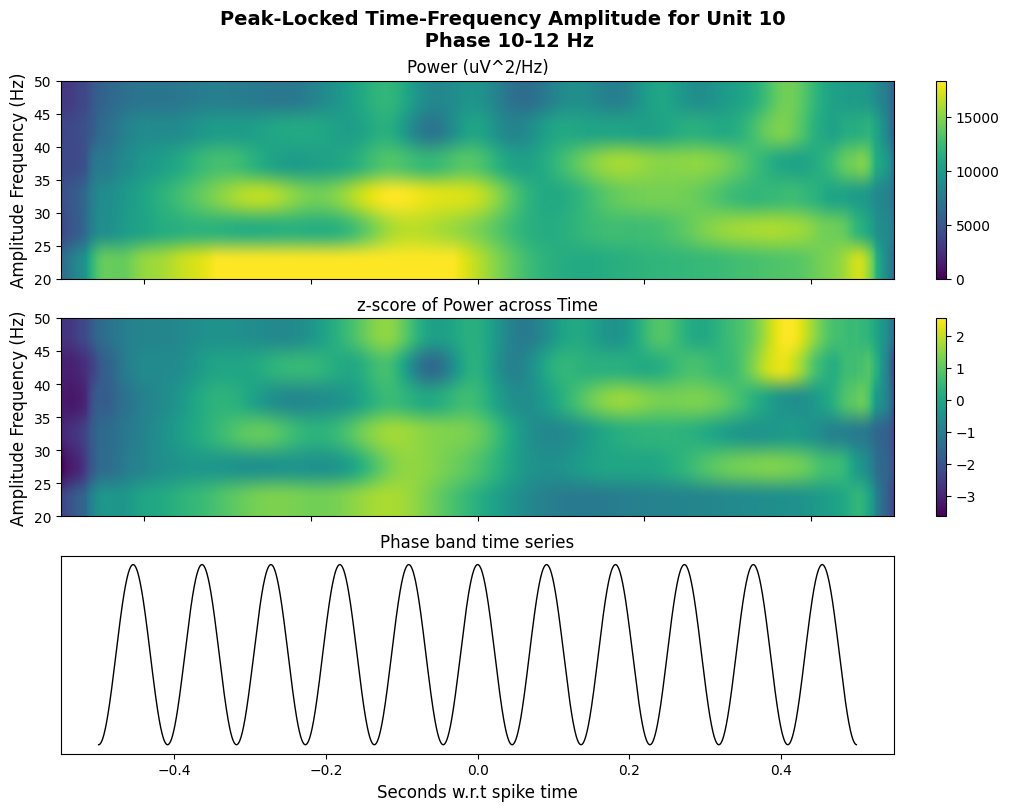

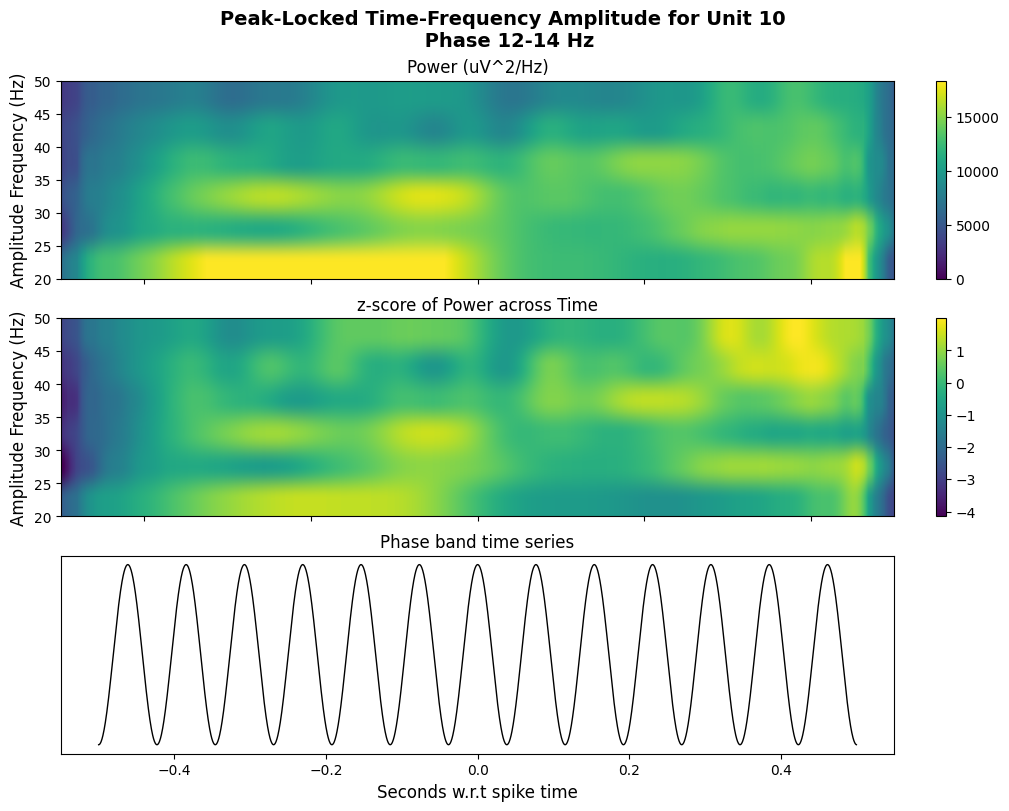

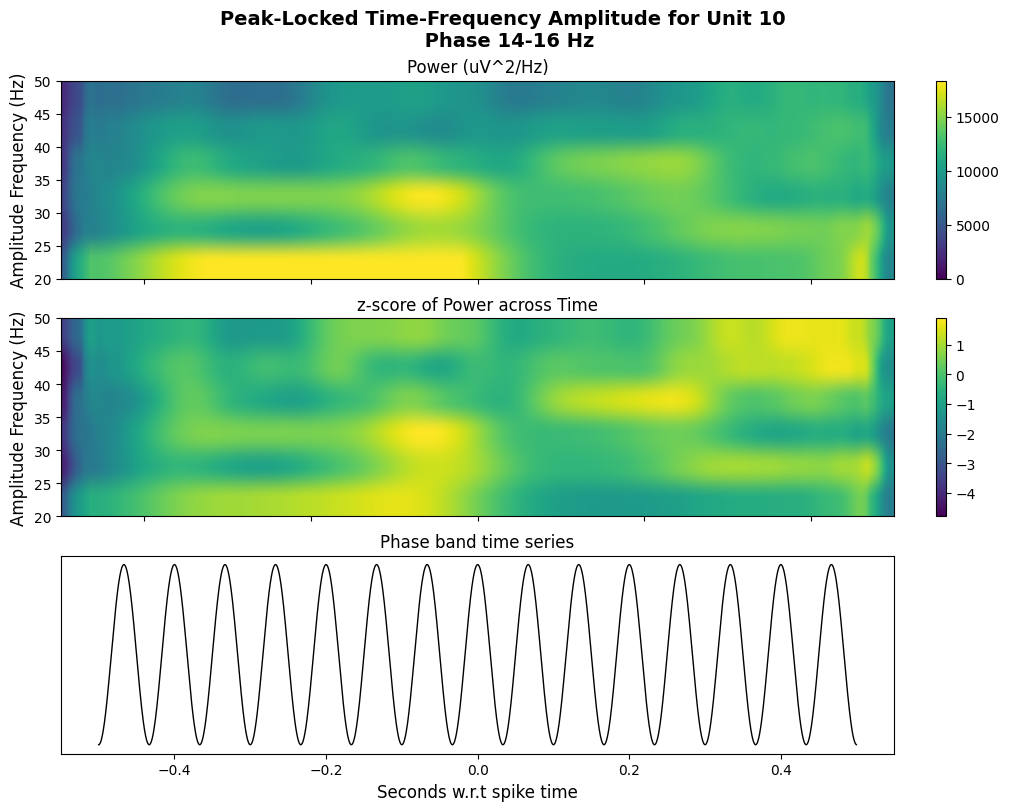

In [105]:
# Plot peak locked time-frequency amplitude for each frequency band (separate figure per phase band)

# fetch frequency bands
f_pha, f_amp = (frame.PhaseAmplitudeBands & event_pac_key).fetch1("f_pha", "f_amp")

# get time vector
t = (frame.EventBasedCoupling & event_pac_key).fetch1("t")

# fetch peak locked time-frequency amplitude results
pltf_array = (frame.EventBasedCoupling.PeakLockedTF & event_pac_key).fetch1("pltf_array")

# get z-scores (across time)
z_scores = (pltf_array - np.mean(pltf_array, axis=2, keepdims=True)) / np.std(pltf_array, axis=2, keepdims=True)

cmin = 0
cmax = np.percentile(pltf_array, 95)

for i, phase_band in enumerate(f_pha):
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), constrained_layout=True)
    fig.suptitle(
        f'Peak-Locked Time-Frequency Amplitude for Unit {unit_id} \n Phase {phase_band[0]}-{phase_band[1]} Hz',
        fontsize=14,
        fontweight='bold',
    )

    im = axs[0].imshow(
        pltf_array[:, i, :],
        aspect='auto',
        origin='lower',
        extent=[t[0], t[-1], f_amp[0][0], f_amp[-1][1]],
        vmin=cmin,
        vmax=cmax,
        cmap='viridis',
    )
    fig.colorbar(im, ax=axs[0], location='right')
    axs[0].set_title('Power (uV^2/Hz)', fontsize=12)
    axs[0].set_ylabel('Amplitude Frequency (Hz)', fontsize=12)
    axs[0].set_xticklabels([])

    im = axs[1].imshow(
        z_scores[:, i, :],
        aspect='auto',
        origin='lower',
        extent=[t[0], t[-1], f_amp[0][0], f_amp[-1][1]],
        cmap='viridis',
    )
    fig.colorbar(im, ax=axs[1], location='right')
    axs[1].set_title('z-score of Power across Time', fontsize=12)
    axs[1].set_ylabel('Amplitude Frequency (Hz)', fontsize=12)
    axs[1].set_xticklabels([])

    # get phase band oscillation trace
    center_freq = np.mean(phase_band)
    phase_trace = np.cos(2 * np.pi * center_freq * t)
    axs[2].plot(t, phase_trace, color='black', linewidth=1)
    axs[2].set_title('Phase band time series')
    axs[2].set_xlabel('Seconds w.r.t spike time', fontsize=12)
    axs[2].set_yticks([])

    plt.show()